# 1.4 — Pass Networks

Barcelona 6-0 Athletic Club, La Liga 2015/16.
We filter first-half completed passes, calculate average player positions, count connections, and draw the network on the pitch.

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

sys.path.append('/Users/stefanhofmann/Documents/Bewerbung/Portfolio/Blog/assets/helpers')
from data_loader import load_competitions, load_matches, load_events, flatten_events
from pitch import draw_pitch

FIGURES = 'figures'

# Statsbomb stores full legal names. This maps them to the known name.
DISPLAY_NAMES = {
    'Lionel Andrés Messi Cuccittini':   'Messi',
    'Andrés Iniesta Luján':            'Iniesta',
    'Sergio Busquets i Burgos':         'Busquets',
    'Neymar da Silva Santos Junior':    'Neymar',
    'Luis Alberto Suárez Díaz':        'Suárez',
    'Gerard Piqué Bernabéu':           'Piqué',
    'Jordi Alba Ramos':                 'Alba',
    'Claudio Andrés Bravo Muñoz':      'Bravo',
    'Ivan Rakitič':                     'Rakitič',
    'Javier Alejandro Mascherano':      'Mascherano',
    'Aleix Vidal Parreu':               'Vidal',
    'Marc Bartra Aregall':              'Bartra',
    'Sergi Roberto Carnicer':           'Sergi Roberto',
    'Arda Turan':                       'Turan',
    'Sandro Ramírez Castillo':          'Sandro',
    'Munir El Haddadi Mohamed':         'Munir',
}

def display_name(full_name):
    return DISPLAY_NAMES.get(full_name, full_name.split()[-1])

---
## Load the Match

In [2]:
MATCH_ID = 266149

comp_df = load_competitions()
row = comp_df[
    (comp_df['competition_name'] == 'La Liga') &
    (comp_df['season_name'] == '2015/2016')
].iloc[0]

matches = load_matches(row['competition_id'], row['season_id'])
match_row = matches[matches['match_id'] == MATCH_ID].iloc[0]

home_team = match_row['home_team']['home_team_name']
away_team  = match_row['away_team']['away_team_name']

print(f'{home_team} {match_row["home_score"]}-{match_row["away_score"]} {away_team}')

Barcelona 6-0 Athletic Club


---
## Filter: Completed First-Half Passes

In [3]:
raw = load_events(MATCH_ID)
df  = flatten_events(raw)

passes = df[
    (df['type'] == 'Pass') &
    (df['team'] == home_team) &
    (df['period'] == 1) &
    (df['pass_outcome'].isna())
].copy()

print(f'Completed first-half passes by {home_team}: {len(passes)}')

Completed first-half passes by Barcelona: 337


---
## Average Player Positions

In [4]:
touches = df[
    (df['team'] == home_team) &
    (df['period'] == 1) &
    df['x'].notna()
].copy()

avg_positions = (
    touches.groupby('player')[['x', 'y']]
    .mean()
    .rename(columns={'x': 'avg_x', 'y': 'avg_y'})
)

print(avg_positions.sort_values('avg_x'))

                                    avg_x      avg_y
player                                              
Claudio Andrés Bravo Muñoz      13.957778  39.391111
Javier Alejandro Mascherano     47.290833  27.626667
Gerard Piqué Bernabéu           48.537374  55.509091
Sergio Busquets i Burgos        59.669912  32.721239
Jordi Alba Ramos                61.580272  11.453061
Aleix Vidal Parreu              68.540909  68.759091
Andrés Iniesta Luján            69.667763  22.701974
Ivan Rakitić                    73.702970  51.369307
Lionel Andrés Messi Cuccittini  81.291176  52.505147
Luis Alberto Suárez Díaz        85.638298  36.697872
Neymar da Silva Santos Junior   86.117419  15.443871


---
## Pass Connection Matrix

In [5]:
pass_counts = (
    passes.groupby(['player', 'pass_recipient'])
    .size()
    .reset_index(name='count')
)

pass_counts = pass_counts[pass_counts['count'] >= 3]
print(f'Connections with 3+ passes: {len(pass_counts)}')
print(pass_counts.sort_values('count', ascending=False).head(10).to_string())

Connections with 3+ passes: 52
                         player                  pass_recipient  count
52             Jordi Alba Ramos   Neymar da Silva Santos Junior     15
21        Gerard Piqué Bernabéu              Aleix Vidal Parreu     12
2            Aleix Vidal Parreu                    Ivan Rakitić     10
41  Javier Alejandro Mascherano                Jordi Alba Ramos     10
4            Aleix Vidal Parreu  Lionel Andrés Messi Cuccittini     10
11         Andrés Iniesta Luján                Jordi Alba Ramos      9
38  Javier Alejandro Mascherano            Andrés Iniesta Luján      9
25        Gerard Piqué Bernabéu     Javier Alejandro Mascherano      8
77     Sergio Busquets i Burgos              Aleix Vidal Parreu      8
14         Andrés Iniesta Luján        Sergio Busquets i Burgos      8


---
## Draw the Network

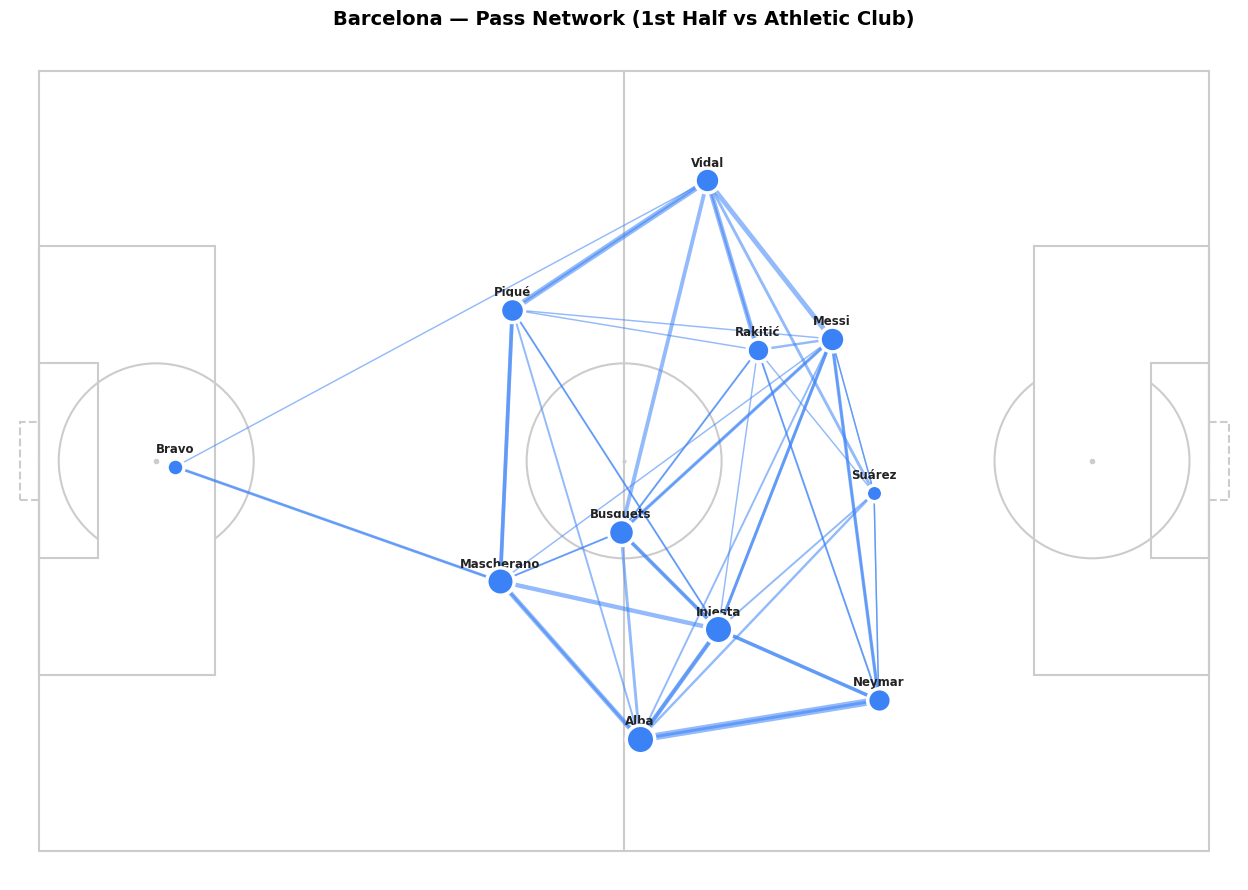

In [6]:
fig, ax = plt.subplots(figsize=(14, 9))
draw_pitch(ax, color='#f8f8f8', line_color='#cccccc')

players_in_network = set(pass_counts['player']) | set(pass_counts['pass_recipient'])

# Edges
for _, row in pass_counts.iterrows():
    if row['player'] not in avg_positions.index:
        continue
    if row['pass_recipient'] not in avg_positions.index:
        continue
    x1, y1 = avg_positions.loc[row['player'],         ['avg_x', 'avg_y']]
    x2, y2 = avg_positions.loc[row['pass_recipient'], ['avg_x', 'avg_y']]
    ax.plot([x1, x2], [y1, y2],
            color='#3b82f6', linewidth=row['count'] * 0.35,
            alpha=0.55, zorder=2)

# Nodes
for player, pos in avg_positions.iterrows():
    if player not in players_in_network:
        continue
    total = passes[passes['player'] == player].shape[0]
    ax.scatter(pos['avg_x'], pos['avg_y'],
               s=total * 10,
               color='#3b82f6', edgecolors='white',
               linewidths=2.5, zorder=4)
    ax.annotate(display_name(player),
                (pos['avg_x'], pos['avg_y']),
                textcoords='offset points', xytext=(0, 10),
                fontsize=8.5, ha='center', fontweight='bold', color='#222')

ax.set_title(f'{home_team} — Pass Network (1st Half vs {away_team})',
             fontweight='bold', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig(f'{FIGURES}/pass_network_barcelona.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Bonus: First Half vs. Second Half

In [7]:
passes_h2 = df[
    (df['type'] == 'Pass') &
    (df['team'] == home_team) &
    (df['period'] == 2) &
    (df['pass_outcome'].isna())
].copy()

touches_h2 = df[
    (df['team'] == home_team) &
    (df['period'] == 2) &
    df['x'].notna()
].copy()

avg_pos_h2 = (
    touches_h2.groupby('player')[['x', 'y']]
    .mean()
    .rename(columns={'x': 'avg_x', 'y': 'avg_y'})
)

pass_counts_h2 = (
    passes_h2.groupby(['player', 'pass_recipient'])
    .size()
    .reset_index(name='count')
)
pass_counts_h2 = pass_counts_h2[pass_counts_h2['count'] >= 3]

print(f'H1 connections: {len(pass_counts)}')
print(f'H2 connections: {len(pass_counts_h2)}')

H1 connections: 52
H2 connections: 53


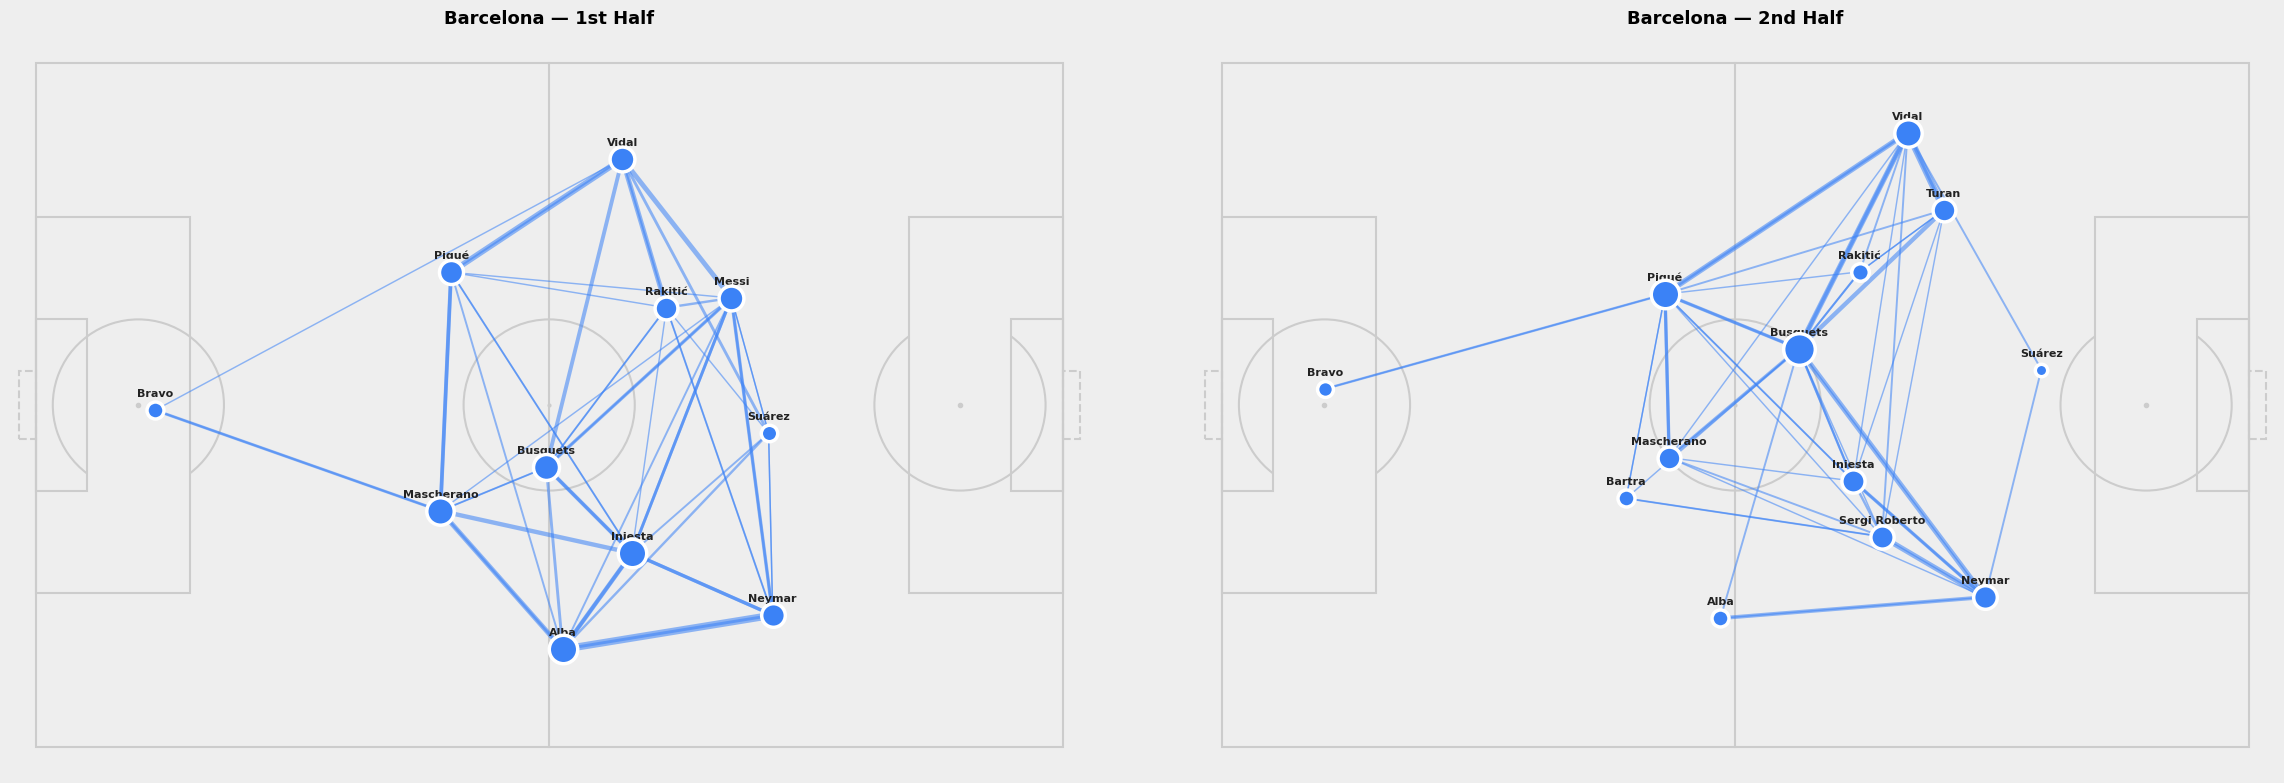

In [8]:
def draw_network(ax, passes_df, avg_pos, pass_cnts, title):
    draw_pitch(ax, color='#f8f8f8', line_color='#cccccc')
    players = set(pass_cnts['player']) | set(pass_cnts['pass_recipient'])
    for _, row in pass_cnts.iterrows():
        if row['player'] not in avg_pos.index or row['pass_recipient'] not in avg_pos.index:
            continue
        x1, y1 = avg_pos.loc[row['player'],         ['avg_x', 'avg_y']]
        x2, y2 = avg_pos.loc[row['pass_recipient'], ['avg_x', 'avg_y']]
        ax.plot([x1, x2], [y1, y2], color='#3b82f6',
                linewidth=row['count'] * 0.35, alpha=0.55, zorder=2)
    for player, pos in avg_pos.iterrows():
        if player not in players:
            continue
        total = passes_df[passes_df['player'] == player].shape[0]
        ax.scatter(pos['avg_x'], pos['avg_y'], s=total * 10,
                   color='#3b82f6', edgecolors='white', linewidths=2.5, zorder=4)
        ax.annotate(display_name(player), (pos['avg_x'], pos['avg_y']),
                    textcoords='offset points', xytext=(0, 10),
                    fontsize=8, ha='center', fontweight='bold', color='#222')
    ax.set_title(title, fontweight='bold', fontsize=13, pad=10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))
fig.patch.set_facecolor('#eeeeee')

draw_network(ax1, passes,    avg_positions, pass_counts,    f'{home_team} — 1st Half')
draw_network(ax2, passes_h2, avg_pos_h2,   pass_counts_h2, f'{home_team} — 2nd Half')

plt.tight_layout(pad=2)
plt.savefig(f'{FIGURES}/pass_network_both_halves.png', dpi=150, bbox_inches='tight')
plt.show()

---
**Next: [1.5 — Heatmaps](../1.5_Heatmaps/notebook.ipynb)**